# YOLO11: настройка масок и независимая проверка

Обучение уже завершено. Этот ноутбук **не обучает модель**, не меняет `best.pt`, исходные изображения или ручную разметку.

1. Подбирает confidence и запас рамки **только на 40 validation-кропах**.
2. Фиксирует выбранную настройку вместе с хешами весов, разметки и кода.
3. По отдельному флагу проверяет её на 40 holdout-кропах. После этого не подбирайте параметры по holdout.

Повторный Run All использует готовые результаты. Частично выполненный проход возобновляется из кэша на том же устройстве. Для запуска контрольной проверки поставьте `RUN_HOLDOUT = True`; обучение включать нигде не нужно.

In [1]:
from pathlib import Path
import sys, json

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'backend/core.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from training.mask_finetune import EXPERIMENT, load_json
from training.mask_calibration import calibrate_masks, evaluate_frozen_holdout, CONFIDENCES, MARGINS, LIMITS
from training.yolo_masks import device_name

RUN_CALIBRATION = True  # готовая калибровка будет прочитана без пересчёта
RUN_HOLDOUT = True  # True — однократная проверка уже зафиксированных настроек
SHOW_VALIDATION_EXAMPLES = True
RUN_DIR = EXPERIMENT / 'runs/pilot_01'
WEIGHTS = RUN_DIR / 'weights/best.pt'
ANNOTATIONS = EXPERIMENT / 'annotation/reviewed_masks.json'
CALIBRATION_DIR = RUN_DIR / 'calibration_v1'
DEVICE = device_name()
print('Device for new inference:', DEVICE)
print('Weights:', WEIGHTS)
print('Output:', CALIBRATION_DIR)
print('Это только inference и оценка, не обучение.')

Device for new inference: mps
Weights: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/YOLO11/variant_01_anonymized_regions/runs/pilot_01/weights/best.pt
Output: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/YOLO11/variant_01_anonymized_regions/runs/pilot_01/calibration_v1
Это только inference и оценка, не обучение.


## 1. Фиксированные правила выбора

49 сочетаний порога и запаса рамки. Детектор выполняет один проход по validation с confidence 0.05; следующие пороги фильтруют этот кэш. Расширяем **неокруглённые** координаты, затем округляем наружу и ограничиваем границами кропа.

Лишняя маска допускается максимум на 3% общей площади кропов и 10% одного кропа. Среди допустимых вариантов максимизируем число областей с покрытием ≥90%; затем покрытую площадь; при равенстве предпочитаем меньше лишней площади. Это эвристики пилота, не гарантии качества и не требования организаторов.

Сравнение — с заранее заданными `confidence=0.25, margin=0`. Margin 0.10 означает добавление 10% ширины и высоты рамки **с каждой стороны**. Настройка фиксируется до открытия holdout. Код проверяет неизменность весов и данных.

In [2]:
print('Confidence:', CONFIDENCES)
print('Margin:', MARGINS)
print('Area limits:', LIMITS)
validation = None
if RUN_CALIBRATION:
    validation = calibrate_masks(WEIGHTS, ANNOTATIONS, CALIBRATION_DIR, device=DEVICE)
    print('Frozen settings:', validation['selected'])
    print('Actual cached inference device:', validation['device'])
else:
    print('Калибровка выключена. Holdout потребует ранее сохранённый calibration.json.')

Confidence: (0.05, 0.1, 0.15, 0.2, 0.25, 0.35, 0.5)
Margin: (0.0, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2)
Area limits: {'outside_fraction_of_all_crops': 0.03, 'outside_fraction_of_any_crop': 0.1}
Reuse frozen calibration; no inference or training
Frozen settings: {'confidence': 0.2, 'margin': 0.1}
Actual cached inference device: cpu


## 2. Покрытие размытия, а не mAP поиска автомобилей

Числа ниже сравнивают автоматические маски с ручными прямоугольниками. «Покрыто ≥90%» не означает полного скрытия всей области. Лишняя площадь — пиксели вне ручной разметки, а не обязательно отдельные ложные детекции. На кадрах без размытия специфичность пока неизвестна: отрицательных примеров в этой выборке нет.

In [3]:
import pandas as pd
from IPython.display import display

def show_summary(report):
    rows = []
    for name in ('baseline', 'calibrated'):
        s = report[name]['coverage']
        rows.append({'Вариант': name, 'Кропы': s['crops'], 'Области': s['reference_regions'],
            'Покрытие площади, %': 100*s['reference_pixel_coverage'],
            'Областей закрыто ≥90%': s['regions_covered_90pct'],
            'Полностью пропущено': s['regions_zero_coverage'],
            'Лишняя площадь всех кропов, %': 100*s['outside_reference_fraction_of_crop'],
            'Макс. лишняя площадь одного кропа, %': 100*s['max_outside_reference_fraction_of_crop']})
    display(pd.DataFrame(rows).round(2))
    print('Split:', report['split'], '| settings:', report['selected'])
    if report['calibrated']['coverage']['negative_images'] == 0:
        print('Нет отрицательных кадров: частота ложных масок на чистых изображениях НЕ измерена.')

if validation is not None:
    show_summary(validation)
    grid = pd.DataFrame([{'confidence': r['confidence'], 'margin': r['margin'],
        'regions90': r['coverage']['regions_covered_90pct'],
        'coverage_pct': 100*r['coverage']['reference_pixel_coverage'],
        'outside_pct': 100*r['coverage']['outside_reference_fraction_of_crop'],
        'worst_outside_pct': 100*r['coverage']['max_outside_reference_fraction_of_crop']}
        for r in validation['leaderboard']])
    display(grid.sort_values(['regions90', 'coverage_pct'], ascending=False).round(3))

,Вариант,Кропы,Области,"Покрытие площади, %",Областей закрыто ≥90%,Полностью пропущено,"Лишняя площадь всех кропов, %","Макс. лишняя площадь одного кропа, %"
0,baseline,40,49,84.11,30,3,0.97,6.55
1,calibrated,40,49,91.51,43,2,2.98,9.60


Split: val | settings: {'confidence': 0.2, 'margin': 0.1}
Нет отрицательных кадров: частота ложных масок на чистых изображениях НЕ измерена.


,confidence,margin,regions90,coverage_pct,outside_pct,worst_outside_pct
6,0.05,0.200,48,94.317,6.118,19.441
13,0.10,0.200,47,94.124,5.643,14.327
20,0.15,0.200,46,93.641,5.534,13.127
27,0.20,0.200,46,93.641,5.522,13.127
5,0.05,0.150,46,93.456,4.737,16.892
34,0.25,0.200,45,93.430,5.334,13.127
12,0.10,0.150,45,93.263,4.311,12.490
4,0.05,0.100,45,92.251,3.456,14.470
19,0.15,0.150,44,92.781,4.214,11.350
26,0.20,0.150,44,92.781,4.203,11.350


## 3. Сложные validation-примеры

Для каждого кропа: слева ручная разметка (зелёная), в центре выбранные автоматические рамки (синие), справа непрозрачные чёрные маски. Это просмотр **validation**, не holdout. Исходные PNG не меняются.

b066e055ef4a444c918a2cb209d6f72b | coverage per region: [1.0, 0.0]


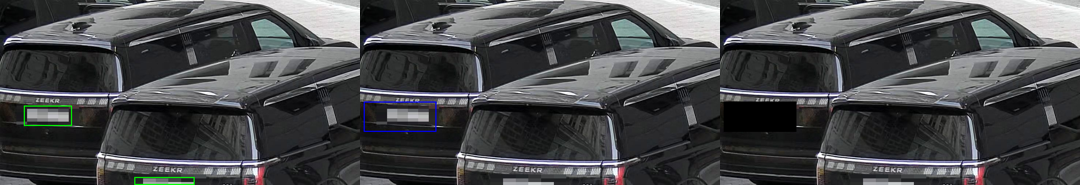

c77f5263ef81462290a5305d030a298d | coverage per region: [1.0, 0.0]


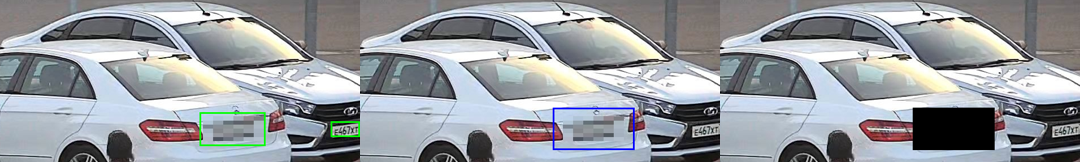

45223b3a34ec4fa9a61ff46ea46a3dc6 | coverage per region: [0.346, 1.0]


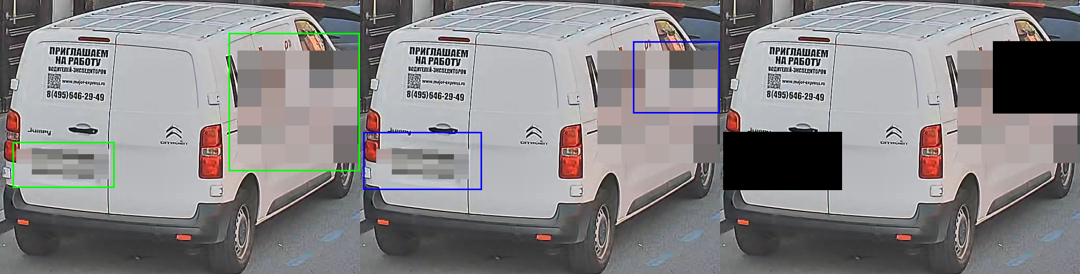

ea76e8e4ab1941f6892a878ba7db0f76 | coverage per region: [0.835]


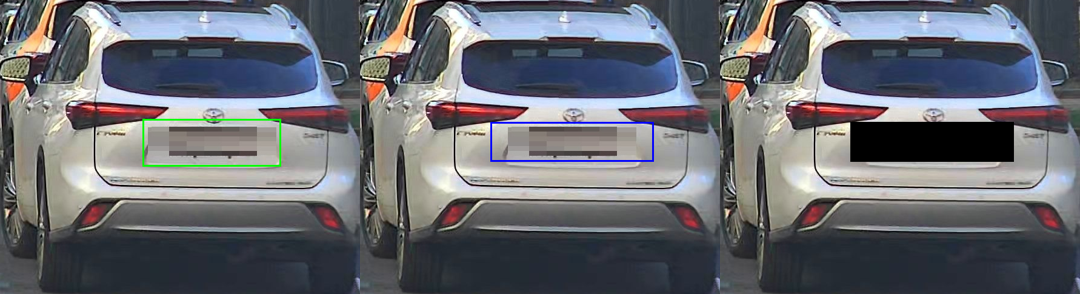

83e6013ec61e4ebe852e76fe51b8460f | coverage per region: [0.857]


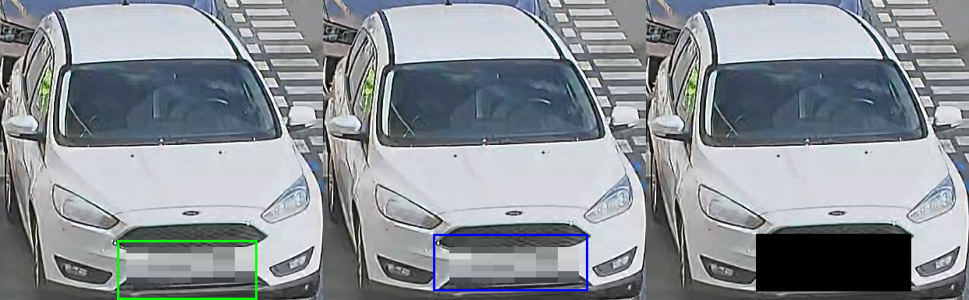

cd6da87750ba4a62851f8269d2137541 | coverage per region: [0.889]


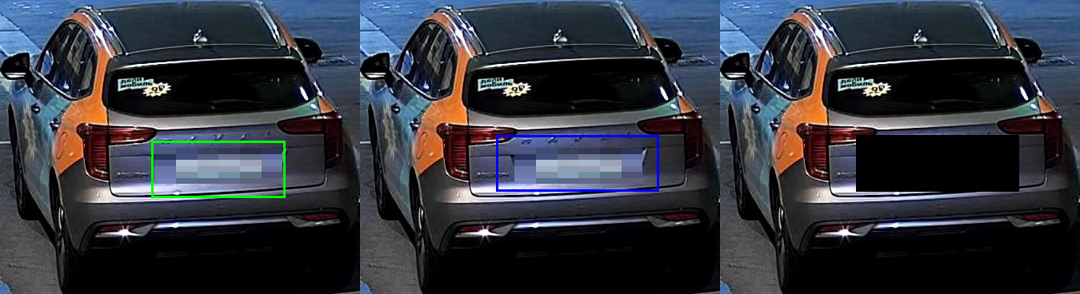

In [4]:
if SHOW_VALIDATION_EXAMPLES and validation is not None:
    from PIL import Image, ImageDraw
    from training.audit import opaque_mask
    manual = load_json(ANNOTATIONS)['images']
    per_image = validation['calibrated']['per_image']
    worst = sorted(per_image, key=lambda i: min(per_image[i]['region_coverages'], default=1))[:6]
    for image_id in worst:
        with Image.open(EXPERIMENT / 'data/images/val' / f'{image_id}.png') as source:
            original = source.convert('RGB')
        predicted = validation['calibrated']['predictions'][image_id]['rectangles']
        panes = [original.copy(), original.copy(), opaque_mask(original, predicted)]
        for pane, rects, color in [(panes[0], manual[image_id]['rectangles'], 'lime'),
                                    (panes[1], predicted, 'blue')]:
            draw = ImageDraw.Draw(pane)
            for x1, y1, x2, y2 in rects:
                draw.rectangle((x1, y1, x2-1, y2-1), outline=color, width=3)
        for pane in panes:
            pane.thumbnail((360, 300))
        preview = Image.new('RGB', (sum(p.width for p in panes), max(p.height for p in panes)), 'white')
        left = 0
        for pane in panes:
            preview.paste(pane, (left, 0))
            left += pane.width
        print(image_id, '| coverage per region:', [round(x, 3) for x in per_image[image_id]['region_coverages']])
        display(preview)

## 4. Независимый holdout — только после фиксации параметров

Для запуска измените **только** `RUN_HOLDOUT = True` в первой ячейке и выполните Run All. Предыдущие результаты калибровки переиспользуются, обучение не запускается. На holdout сравниваются ровно два заранее заданных варианта: исходный и выбранный на validation. Перебора параметров здесь нет.

Повторный запуск читает сохранённый `holdout_final.json`. При изменении модели, разметки, кода или калибровки старые результаты не перезаписываются. Если выполнение прервалось, Run All продолжит предсказания из кэша. Не удаляйте результаты и не меняйте настройки ради улучшения числа на этой контрольной выборке.

In [5]:
if RUN_HOLDOUT:
    holdout = evaluate_frozen_holdout(WEIGHTS, ANNOTATIONS, CALIBRATION_DIR,
        confirm=True, device=DEVICE)
    show_summary(holdout)
    print('Saved:', CALIBRATION_DIR / 'holdout_final.json')
else:
    print('Holdout не запускался. Для независимой проверки: RUN_HOLDOUT = True → Run All.')

holdout: 10/40 · 3.3 s
holdout: 20/40 · 3.8 s
holdout: 30/40 · 4.1 s
holdout: 40/40 · 4.4 s


,Вариант,Кропы,Области,"Покрытие площади, %",Областей закрыто ≥90%,Полностью пропущено,"Лишняя площадь всех кропов, %","Макс. лишняя площадь одного кропа, %"
0,baseline,40,45,92.3,37,3,0.84,2.02
1,calibrated,40,45,97.6,42,2,2.50,4.73


Split: holdout | settings: {'confidence': 0.2, 'margin': 0.1}
Нет отрицательных кадров: частота ложных масок на чистых изображениях НЕ измерена.
Saved: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/YOLO11/variant_01_anonymized_regions/runs/pilot_01/calibration_v1/holdout_final.json


## Следующий шаг

После holdout — отдельное сравнение ReID без масок и с зафиксированным детектором. Этот ноутбук не меняет MVP, не маскирует весь датасет и не доказывает улучшение поиска автомобилей. Возвращать исторический обучающий ноутбук в режим Run All сейчас не нужно.